Dataset Description:
The dataset consists of the following variables:
Age: Age in years
KM: Accumulated Kilometers on odometer
FuelType: Fuel Type (Petrol, Diesel, CNG)
HP: Horse Power
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters
Doors: Number of doors
Weight: Weight in Kilograms
Quarterly_Tax:
Price: Offer Price in EUROs

In [2]:
import pandas as pd
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


### 1. Dataset Information and Summary Statistics

In [ ]:
# Drop the 'Cylinders' column as it has only one unique value
df.drop('Cylinders', axis=1, inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Gears      1436 non-null   int64 
 9   Weight     1436 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 112.3+ KB
None


### 2. Visualizations

#### Distribution of Numerical Variables

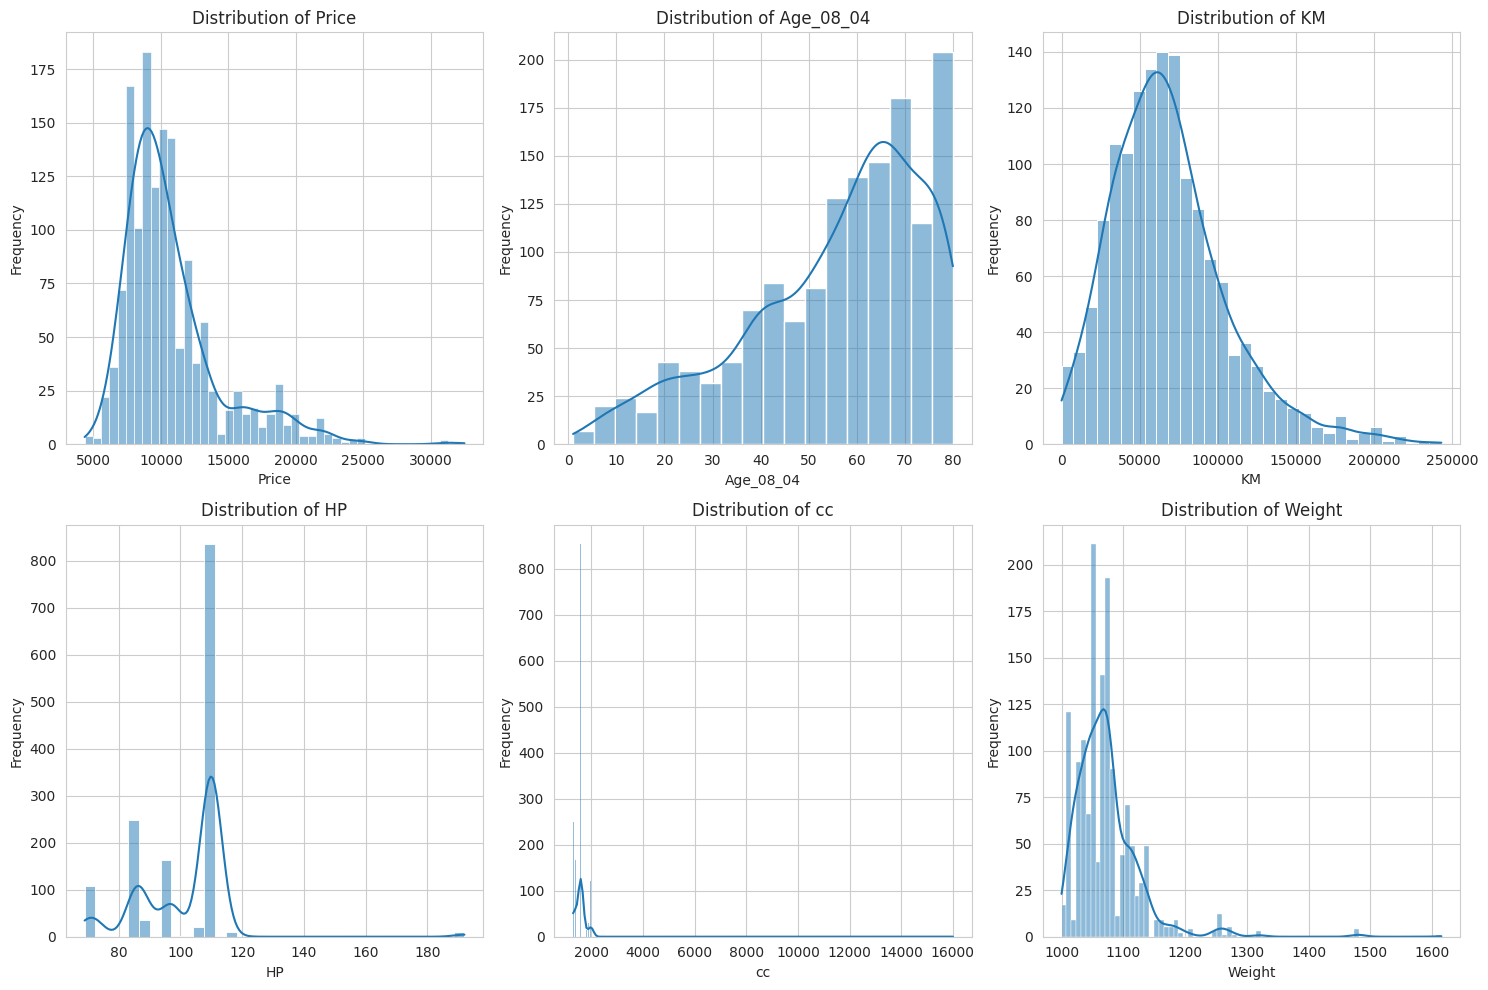

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# List of numerical columns to plot (excluding 'Cylinders' which was dropped)
numerical_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Weight']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Distribution of Categorical Variables

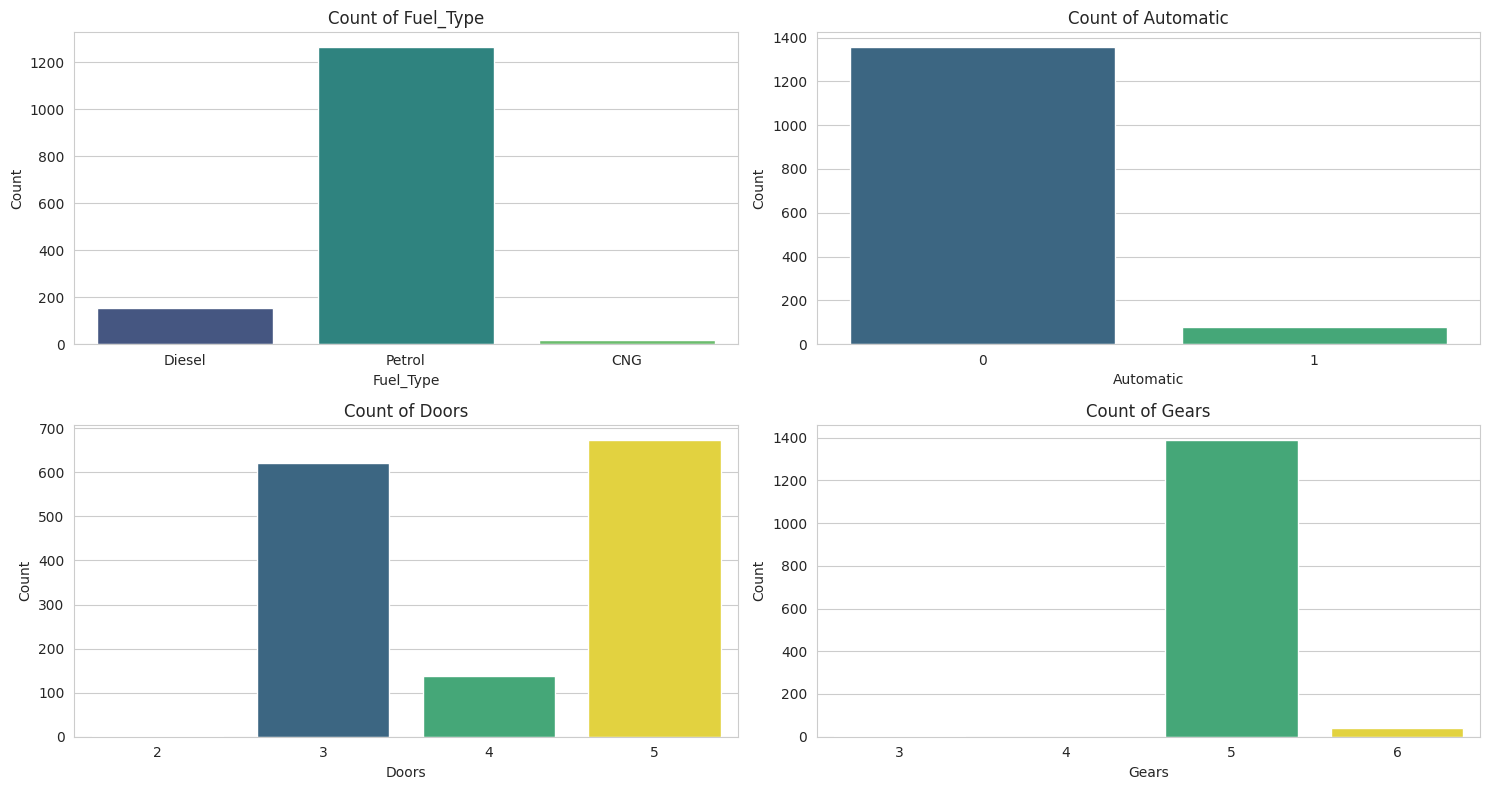

In [ ]:
categorical_cols = ['Fuel_Type', 'Automatic', 'Doors', 'Gears']

plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Relationships with Price (Target Variable)

##### Numerical Variables vs. Price (Scatter Plots)

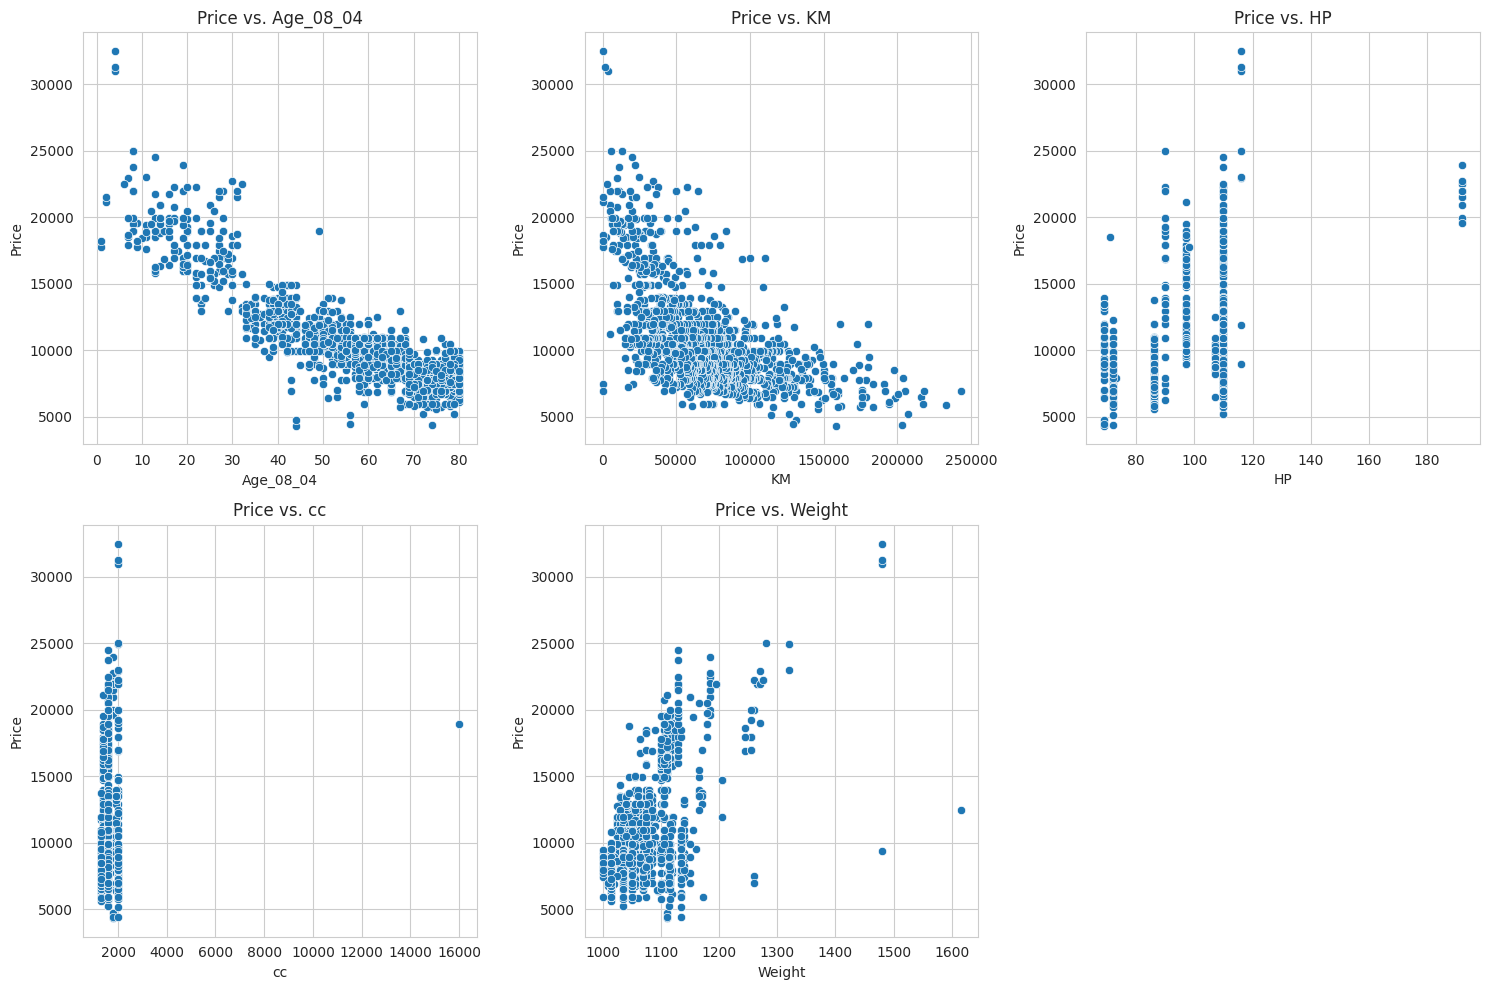

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Age_08_04', 'KM', 'HP', 'cc', 'Weight']):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'Price vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

##### Categorical Variables vs. Price (Box Plots)

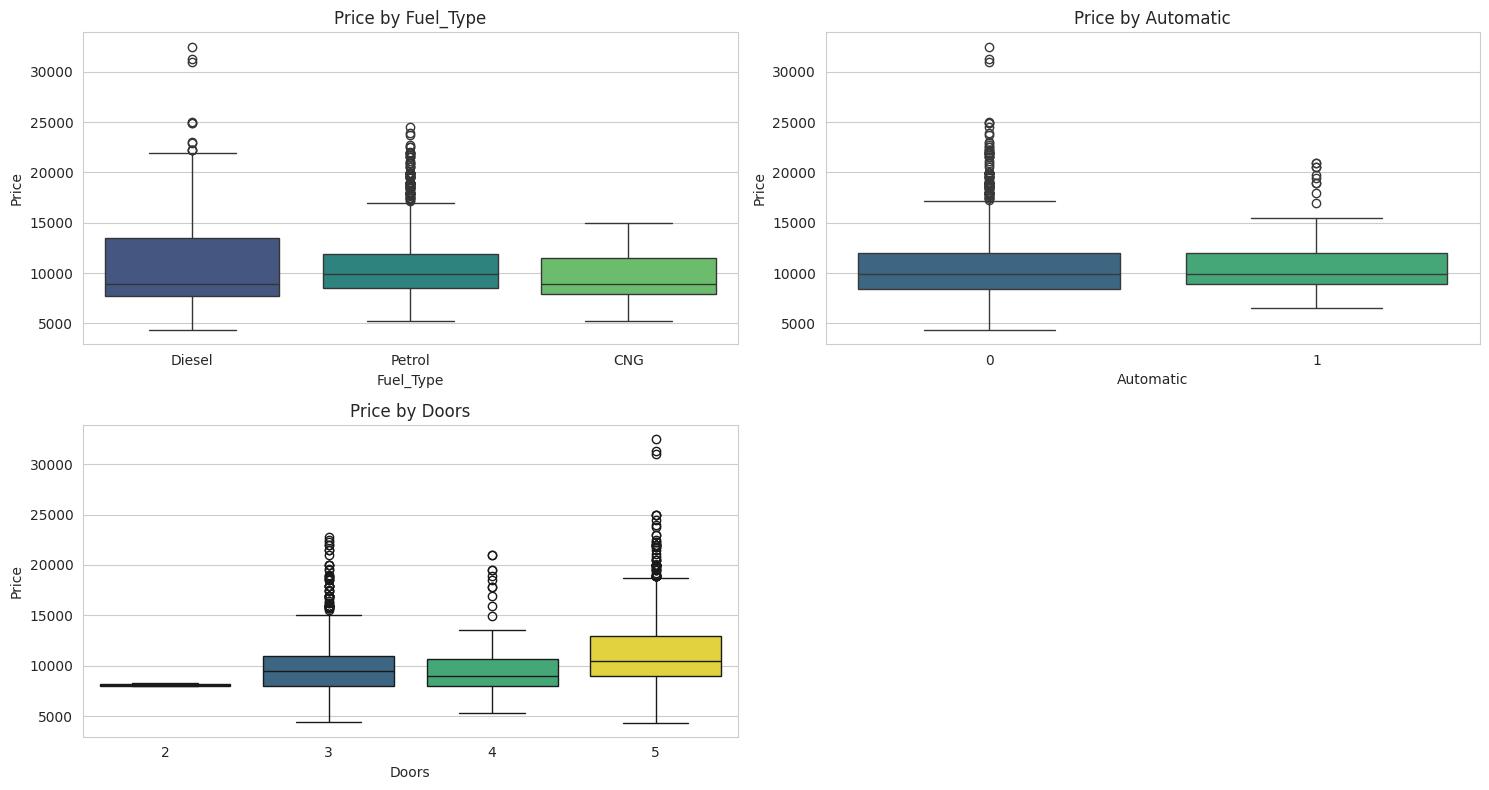

In [ ]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(['Fuel_Type', 'Automatic', 'Doors']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

#### Correlation Matrix

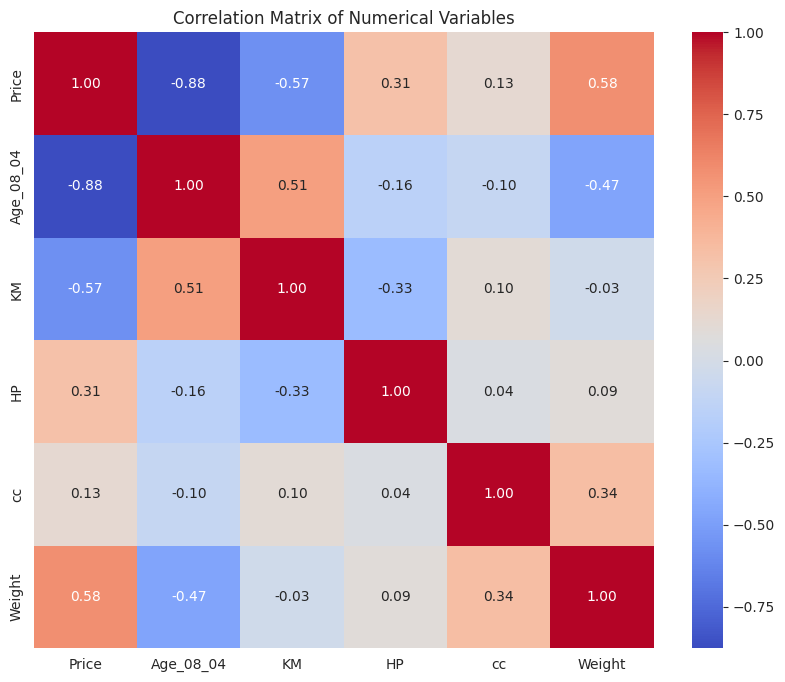

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### 3. Data Pre-processing for MLR

#### One-Hot Encoding for Categorical Variables

In [ ]:
# Apply one-hot encoding to 'Fuel_Type' and 'Doors'
df_processed = pd.get_dummies(df, columns=['Fuel_Type', 'Doors'], drop_first=True)

print("DataFrame after One-Hot Encoding:")
print(df_processed.head())

DataFrame after One-Hot Encoding:
   Price  Age_08_04     KM  HP  Automatic    cc  Gears  Weight  \
0  13500         23  46986  90          0  2000      5    1165   
1  13750         23  72937  90          0  2000      5    1165   
2  13950         24  41711  90          0  2000      5    1165   
3  14950         26  48000  90          0  2000      5    1165   
4  13750         30  38500  90          0  2000      5    1170   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Doors_3  Doors_4  Doors_5  
0              True             False     True    False    False  
1              True             False     True    False    False  
2              True             False     True    False    False  
3              True             False     True    False    False  
4              True             False     True    False    False  


#### Splitting Data into Features (X) and Target (y)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Identify numerical columns for scaling (excluding binary and one-hot encoded features)
# Based on df_processed columns after one-hot encoding: Age_08_04, KM, HP, cc, Gears, Weight

numerical_features_for_scaling = ['Age_08_04', 'KM', 'HP', 'cc', 'Gears', 'Weight']

# Initialize StandardScaler
scaler = StandardScaler()

# Create copies of training and testing features to avoid modifying original X_train, X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply scaling to numerical features
X_train_scaled[numerical_features_for_scaling] = scaler.fit_transform(X_train[numerical_features_for_scaling])
X_test_scaled[numerical_features_for_scaling] = scaler.transform(X_test[numerical_features_for_scaling])

# Initialize and train the second Multiple Linear Regression model with scaled data
mlr_model_2 = LinearRegression()
mlr_model_2.fit(X_train_scaled, y_train)

print("Model 2 (Scaled Features) training complete.")
print("\nModel Coefficients:")
for feature, coef in zip(X_train_scaled.columns, mlr_model_2.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Model Intercept:", mlr_model_2.intercept_)

# Make predictions on the test set
y_pred_2 = mlr_model_2.predict(X_test_scaled)

# Evaluate the model using the new function
mae_2, mse_2, rmse_2, r2_2 = evaluate_model(y_test, y_pred_2, model_name="Model 2 Evaluation (Scaled Features)")

Model 2 (Scaled Features) training complete.

Model Coefficients:
  Age_08_04: -2257.87
  KM: -611.47
  HP: 175.28
  Automatic: 75.92
  cc: -14.77
  Gears: 117.33
  Weight: 1376.68
  Fuel_Type_Diesel: -182.87
  Fuel_Type_Petrol: 1425.79
  Doors_3: -532.66
  Doors_4: -231.24
  Doors_5: -669.79
Model Intercept: 10095.17891007568

--- Model 2 Evaluation (Scaled Features) Evaluation ---
Mean Absolute Error (MAE): 978.20
Mean Squared Error (MSE): 2232352.83
Root Mean Squared Error (RMSE): 1494.11
R-squared (R2): 0.83


In [ ]:
X = df_processed.drop('Price', axis=1) # Features
y = df_processed['Price'] # Target variable

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (1436, 12)
Shape of y (target): (1436,)


#### Splitting Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 12)
X_test shape: (288, 12)
y_train shape: (1148,)
y_test shape: (288,)


### 4. Model Training and Evaluation - Model 1: Baseline Multiple Linear Regression

In [ ]:
from sklearn.linear_model import Lasso

# Initialize the Lasso Regression model
# Alpha is the regularization strength. A value of 0 is equivalent to Linear Regression.
# We'll start with a common default or a value determined by cross-validation in a real-world scenario.
# For demonstration, let's pick a value and note that it can be tuned.
lasso_model = Lasso(alpha=0.1, random_state=42) # Using alpha=0.1 as an example

# Train the model using the training data (scaled data is generally preferred for regularized models)
lasso_model.fit(X_train_scaled, y_train)

print("Model 4 (Lasso Regression) training complete.")
print("\nModel Coefficients:")
for feature, coef in zip(X_train_scaled.columns, lasso_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Model Intercept:", lasso_model.intercept_)

# Make predictions on the test set
y_pred_4 = lasso_model.predict(X_test_scaled)

# Evaluate the model using the new function
mae_4, mse_4, rmse_4, r2_4 = evaluate_model(y_test, y_pred_4, model_name="Model 4 Evaluation (Lasso Regression)")

Model 4 (Lasso Regression) training complete.

Model Coefficients:
  Age_08_04: -2257.75
  KM: -611.71
  HP: 175.60
  Automatic: 74.43
  cc: -14.69
  Gears: 117.23
  Weight: 1375.55
  Fuel_Type_Diesel: -178.69
  Fuel_Type_Petrol: 1424.92
  Doors_3: -356.10
  Doors_4: -54.09
  Doors_5: -492.75
Model Intercept: 9919.00922343183

--- Model 4 Evaluation (Lasso Regression) Evaluation ---
Mean Absolute Error (MAE): 978.20
Mean Squared Error (MSE): 2231353.12
Root Mean Squared Error (RMSE): 1493.77
R-squared (R2): 0.83


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Calculates and prints common regression evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
    return mae, mse, rmse, r2

Now, let's update the evaluation sections for each model to use this new `evaluate_model` function for better code organization.

#### Interpretation of Coefficients for Model 4 (Lasso Regression):

Lasso (Least Absolute Shrinkage and Selection Operator) regression adds a penalty equal to the absolute value of the magnitude of coefficients. This type of regularization can lead to some coefficients being shrunk exactly to zero, effectively performing feature selection.

*   **Coefficient Shrinkage**: Notice how some coefficients might be smaller compared to the linear regression models, and some might even be exactly zero if the `alpha` value was higher or if the feature had little predictive power.
*   **Feature Selection**: Lasso is particularly useful for feature selection. Features with coefficients shrunk to zero are effectively removed from the model. This can simplify the model and improve interpretability, especially in cases with many features.
*   **Impact of `alpha`**: The `alpha` parameter controls the strength of the regularization. A higher `alpha` leads to more coefficients being shrunk towards zero. Choosing an optimal `alpha` typically involves cross-validation.

5: Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Initialize the Ridge Regression model
# Alpha is the regularization strength. A value of 0 is equivalent to Linear Regression.
ridge_model = Ridge(alpha=1.0, random_state=42) # Using alpha=1.0 as an example

# Train the model using the training data (scaled data is generally preferred for regularized models)
ridge_model.fit(X_train_scaled, y_train)

print("Model 5 (Ridge Regression) training complete.")
print("\nModel Coefficients:")
for feature, coef in zip(X_train_scaled.columns, ridge_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Model Intercept:", ridge_model.intercept_)

# Make predictions on the test set
y_pred_5 = ridge_model.predict(X_test_scaled)

# Evaluate the model using the new function
mae_5, mse_5, rmse_5, r2_5 = evaluate_model(y_test, y_pred_5, model_name="Model 5 Evaluation (Ridge Regression)")

Model 5 (Ridge Regression) training complete.

Model Coefficients:
  Age_08_04: -2255.03
  KM: -616.57
  HP: 178.40
  Automatic: 79.22
  cc: -14.83
  Gears: 118.06
  Weight: 1368.55
  Fuel_Type_Diesel: -228.76
  Fuel_Type_Petrol: 1346.25
  Doors_3: -244.84
  Doors_4: 52.88
  Doors_5: -377.28
Model Intercept: 9880.363651370966

--- Model 5 Evaluation (Ridge Regression) Evaluation ---
Mean Absolute Error (MAE): 978.20
Mean Squared Error (MSE): 2224682.55
Root Mean Squared Error (RMSE): 1491.54
R-squared (R2): 0.83


#### Interpretation of Coefficients for Model 5 (Ridge Regression):

Ridge regression adds a penalty equal to the *square* of the magnitude of coefficients. This type of regularization shrinks the coefficients towards zero but does not set them exactly to zero. It is particularly effective in dealing with multicollinearity.

*   **Coefficient Shrinkage**: Like Lasso, Ridge regression shrinks coefficients, but it typically doesn't eliminate them entirely (unless `alpha` is extremely large). This means all features will still contribute to the prediction, but their impact will be reduced.
*   **Multicollinearity Handling**: Ridge regression is good at handling multicollinearity by shrinking coefficients of correlated features proportionally. This helps stabilize the model and prevent large coefficient swings due to highly correlated predictors.
*   **Impact of `alpha`**: The `alpha` parameter controls the strength of the regularization. A higher `alpha` leads to greater shrinkage of coefficients. Choosing an optimal `alpha` typically involves cross-validation.

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Multiple Linear Regression model
mlr_model_1 = LinearRegression()

# Train the model using the training data
mlr_model_1.fit(X_train, y_train)

print("Model 1 (Baseline) training complete.")
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, mlr_model_1.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Model Intercept:", mlr_model_1.intercept_)

# Make predictions on the test set
y_pred_1 = mlr_model_1.predict(X_test)

# Evaluate the model using the new function
mae_1, mse_1, rmse_1, r2_1 = evaluate_model(y_test, y_pred_1, model_name="Model 1 Evaluation (Baseline)")

Model 1 (Baseline) training complete.

Model Coefficients:
  Age_08_04: -120.33
  KM: -0.02
  HP: 11.81
  Automatic: 75.92
  cc: -0.03
  Gears: 591.89
  Weight: 27.06
  Fuel_Type_Diesel: -182.87
  Fuel_Type_Petrol: 1425.79
  Doors_3: -532.66
  Doors_4: -231.24
  Doors_5: -669.79
Model Intercept: -15227.90608146066

--- Model 1 Evaluation (Baseline) Evaluation ---
Mean Absolute Error (MAE): 978.20
Mean Squared Error (MSE): 2232352.83
Root Mean Squared Error (RMSE): 1494.11
R-squared (R2): 0.83


#### Interpretation of Coefficients for Model 1 (Baseline):

Each coefficient represents the change in the predicted `Price` for a one-unit increase in the corresponding feature, assuming all other features are held constant.

*   **`Age_08_04`**: A negative coefficient implies that older cars (higher `Age_08_04`) tend to have lower prices, which is expected due to depreciation.
*   **`KM`**: A negative coefficient suggests that cars with more kilometers driven (`KM`) tend to have lower prices, also consistent with depreciation.
*   **`HP`**: A positive coefficient indicates that higher horsepower (`HP`) is associated with a higher price.
*   **`Automatic`**: A coefficient for a binary variable (0 or 1) means that if the car is automatic (1), its price is higher/lower by that amount compared to a manual car (0), holding all else constant.
*   **`cc`**: A positive coefficient indicates that a larger cylinder volume (`cc`) is associated with a higher price.
*   **`Gears`**: A positive coefficient suggests that more gears might be associated with a higher price, though this could also be correlated with car type or performance.
*   **`Weight`**: A positive coefficient means heavier cars are associated with higher prices, possibly reflecting larger or more robust vehicles.
*   **`Fuel_Type_Diesel`**: Compared to the baseline `Fuel_Type` (which is 'CNG' since `drop_first=True` was used and 'Petrol' was also included), a diesel car is associated with a price change by this coefficient.
*   **`Fuel_Type_Petrol`**: Compared to the baseline `Fuel_Type` ('CNG'), a petrol car is associated with a price change by this coefficient.
*   **`Doors_3`, `Doors_4`, `Doors_5`**: These are one-hot encoded for the 'Doors' feature. Each coefficient indicates the price difference compared to the dropped category (which would be 2 doors, if 2 was a category or the first category alphabetically if `drop_first=True` and doors was encoded alphabetically. Given the available Doors values (3,4,5), it's likely the smallest category (3 or 2 if present) was dropped or alphabetically sorted, and these indicate the price difference relative to that base.) More specifically, if the original Doors values were '3', '4', '5' then `drop_first=True` would drop the first category, perhaps `Doors_3`, making `Doors_4` and `Doors_5` relative to `Doors_3`. However, the original `Doors` column had values like 3, 4, 5 and it would keep `Doors_3`, `Doors_4`, `Doors_5` and drop one of them if `drop_first=True`. In `df_processed.head()`, `Doors_3`, `Doors_4`, `Doors_5` are present, which implies one of the original door categories was dropped. Assuming 2 doors was not an option, or it was the first column dropped. If the original data had 3, 4, 5 doors, and `drop_first=True` was used, one of the columns (e.g. `Doors_3`) would be dropped as the reference. So `Doors_4` and `Doors_5` coefficients indicate their price difference compared to a car with 3 doors. If there was a '2' door option, and that was dropped, then it would be relative to '2' doors. Without knowing the exact categories and which was dropped, it is relative to the *reference category*.

### 4. Model Training and Evaluation - Model 2: Multiple Linear Regression with Feature Scaling

#### Interpretation of Coefficients for Model 2 (with Feature Scaling):

When features are scaled (e.g., using `StandardScaler` to have a mean of 0 and standard deviation of 1), the interpretation of coefficients changes slightly. Each coefficient now represents the change in predicted `Price` for a one standard deviation increase in the corresponding feature, holding all other features constant.

The *magnitude* of these scaled coefficients can be compared to understand the relative importance or impact of each feature on the target variable, as they are all on a similar scale. For instance, a larger absolute coefficient value indicates a stronger impact on `Price` for a one standard deviation change in that feature. The signs (positive or negative) still indicate the direction of the relationship, similar to the unscaled model.

### 3: Multiple Linear Regression with `statsmodels`
4. Model Training and Evaluation

In [ ]:
import statsmodels.api as sm

# Convert boolean columns to integers (0 or 1) for statsmodels compatibility
# This conversion should be applied to the original X_train and X_test, not the scaled ones
X_train_sm_processed = X_train.copy()
X_test_sm_processed = X_test.copy()

for col in X_train_sm_processed.select_dtypes(include='bool').columns:
    X_train_sm_processed[col] = X_train_sm_processed[col].astype(int)
for col in X_test_sm_processed.select_dtypes(include='bool').columns:
    X_test_sm_processed[col] = X_test_sm_processed[col].astype(int)

# Add a constant to the independent variables for statsmodels (to represent the intercept)
X_train_sm = sm.add_constant(X_train_sm_processed)
X_test_sm = sm.add_constant(X_test_sm_processed)

# Initialize and train the OLS (Ordinary Least Squares) model from statsmodels
mlr_model_3 = sm.OLS(y_train, X_train_sm)
mlr_model_3_results = mlr_model_3.fit()

print("Model 3 (Statsmodels OLS) training complete.")
print("\n--- Model 3 Summary (Statsmodels OLS) ---")
print(mlr_model_3_results.summary())

# Make predictions on the test set
y_pred_3 = mlr_model_3_results.predict(X_test_sm)

# Evaluate the model using the new function
mae_3, mse_3, rmse_3, r2_3 = evaluate_model(y_test, y_pred_3, model_name="Model 3 Evaluation (Statsmodels OLS)")

Model 3 (Statsmodels OLS) training complete.

--- Model 3 Summary (Statsmodels OLS) ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     639.2
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:59:41   Log-Likelihood:                -9859.5
No. Observations:                1148   AIC:                         1.974e+04
Df Residuals:                    1135   BIC:                         1.981e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

#### Interpretation of Coefficients for Model 3 (Statsmodels OLS):

The `statsmodels` summary provides a more comprehensive statistical overview, including:

*   **`coef`**: Similar to `sklearn`'s coefficients, these represent the change in predicted `Price` for a one-unit increase in the feature, holding others constant.
*   **`std err`**: The standard error of the coefficient, indicating the precision of the coefficient estimate.
*   **`t`**: The t-statistic, which is `coef / std err`. It measures how many standard deviations the coefficient is away from zero.
*   **`P>|t|` (p-value)**: This is a crucial value for hypothesis testing. A low p-value (typically less than 0.05) suggests that the feature is statistically significant in predicting the target variable, meaning we can be confident that its true coefficient is not zero. High p-values indicate that the feature might not be a strong predictor.
*   **`[0.025, 0.975]` (95% Confidence Interval)**: This range indicates that we are 95% confident that the true value of the coefficient lies within this interval.
*   **`R-squared`**: Explains the proportion of variance in the dependent variable that can be predicted from the independent variables.
*   **`Adj. R-squared`**: A modified R-squared that adjusts for the number of predictors in the model. It increases only if the new term improves the model more than would be expected by chance.

By examining the p-values, we can identify which features are statistically significant predictors of car price. Features with high p-values (e.g., >0.05) might not be strong predictors and could potentially be removed for model simplification, though this specific model is built for interpretation.